# Lab 9 Report: 
## Final Project Codebase

## Project Title: Same as your poster title

### Group Members: Simon Harty 

--------------------

In [26]:
from torchvision import transforms
from torchvision.models.vision_transformer import EncoderBlock
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import pandas as pd
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROP_SIZE = 207
INPUT_SIZE = 64
N_WORKERS = 0
RUN = False

DEVICE

device(type='cpu')

## Prepare Data

In [27]:
#make a class to transform and organize data
class GalaxyDataset(Dataset):
    def __init__(self, image_paths, labels_csv, transform=None, cache_path=None):
        self.transform = transform

        if cache_path and Path(cache_path).exists():
            cache = torch.load(cache_path, weights_only=False)
            self.images = cache['images']
            self.galaxy_ids = cache['galaxy_ids']
            self.labels_df = cache['labels_df']
            
        else:
            pre = transforms.Compose([
                transforms.CenterCrop(CROP_SIZE),
                transforms.Resize(INPUT_SIZE),
                transforms.ToTensor(),
            ])
            self.galaxy_ids = [int(p.stem) for p in image_paths]
            self.images = torch.stack([pre(Image.open(p).convert("RGB")) for p in tqdm.tqdm(image_paths)]).half()
            self.labels_df = pd.read_csv(labels_csv, index_col="GalaxyID")

            if cache_path:
                torch.save({'images': self.images,
                            'galaxy_ids': self.galaxy_ids,
                            'labels_df': self.labels_df},
                            cache_path)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        label_values = self.labels_df.loc[self.galaxy_ids[idx]].values
        label = torch.tensor(label_values, dtype=torch.float32, device=img.device)

        return img, label
    
    def __len__(self):
        return len(self.images)

In [28]:
data_dir   = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_training_rev1")
test_dir = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_test_rev1")
labels_csv = r"C:\Users\harty\Code\Galaxy-Classifier\Data\training_solutions_rev1.csv"
data_paths  = sorted(data_dir.glob("*.jpg"))
test_paths = sorted(test_dir.glob("*.jpg"))

indices = torch.randperm(len(data_paths), generator=torch.Generator().manual_seed(42))
n_val   = int(len(data_paths) * 0.1)

train_paths = [data_paths[i] for i in indices[n_val:]]
val_paths   = [data_paths[i] for i in indices[:n_val]]

In [29]:
# load training data to compute average and stdev
train_set = GalaxyDataset(train_paths, labels_csv, transform=None, cache_path='train_set.pth')

# get averages and stdevs for each color in the image
train_mean = train_set.images.mean(dim=[0, 2, 3]).tolist()
train_std = train_set.images.std(dim=[0, 2, 3]).tolist()

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(0, 360)),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# use training means and stds to treat val data as 'unseen'
# do not randomly rotate the validation data for the same reason
val_transform = transforms.Compose([
    transforms.Normalize(mean=train_mean, std=train_std),
])

train_set = GalaxyDataset(train_paths, labels_csv,
                          transform=train_transform,
                          cache_path='train_set.pth')
val_set = GalaxyDataset(val_paths, labels_csv,
                        transform=val_transform,
                        cache_path='val_set.pth')

train_set.images = train_set.images.to(DEVICE)
val_set.images = val_set.images.to(DEVICE)

In [30]:
print(train_mean, train_std)
print(train_set.__len__(), val_set.__len__())

[0.10345458984375, 0.08953857421875, 0.0703125] [0.1444091796875, 0.1209716796875, 0.10443115234375]
55421 6157


## Define Model

In [31]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    """Two conv layers with BN, ReLU, and MaxPool."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.block(x)


class ConvTokenizer(nn.Module):
    """Projects feature map into a sequence of tokens for the transformer."""
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x


class CvTBlock(nn.Module):
    """Uses PyTorch's native, optimized Vision Transformer block."""
    def __init__(self, embed_dim, num_heads, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        
        # PyTorch calculates the hidden MLP dimension directly using mlp_dim
        mlp_dim = int(embed_dim * mlp_ratio)
        
        # Native block combines LayerNorm, MultiheadAttention, and the MLP
        self.transformer_layer = EncoderBlock(
            num_heads=num_heads,
            hidden_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            attention_dropout=dropout,
            norm_layer=nn.LayerNorm
        )

    def forward(self, x):
        return self.transformer_layer(x)


class GalaxyClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        num_outputs: int = 37,
        conv_channels: int = 32,
        embed_dim: int = 32,
        num_heads: int = 2,
        num_cvt_layers: int = 1,
        fc_dim: int = 128,
        dropout: float = 0.5,
    ):
        super().__init__()

        # CNN block
        self.conv_block = ConvBlock(in_channels, conv_channels)

        # CvT block
        self.tokenizer = ConvTokenizer(conv_channels, embed_dim)
        self.cvt = nn.Sequential(
            *[CvTBlock(embed_dim, num_heads, dropout=dropout)
              for _ in range(num_cvt_layers)]
        )

        # FC layers
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim, fc_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim // 2, num_outputs),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.tokenizer(x)
        x = self.cvt(x)
        x = x.mean(dim=1)
        raw_outputs = self.fc(x)
        x = torch.clamp(raw_outputs, 0.0, 1.0)
        return x


model = GalaxyClassifier().to(DEVICE)

dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}")   # expect [4, 37]
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([4, 37])
Params: 34,757


## Define Hyperparameters

In [32]:
BATCH_SIZE = 64
EPOCHS = 24
LR = 1e-3
WD = 1e-2

optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)
loss_func = torch.nn.MSELoss()

## Identify Tracked Values

In [33]:
train_losses = []
val_losses = []

## Train Model

In [34]:
from torch.utils.data import Subset
num_batches = 160

if RUN == True:
    train_subset = Subset(train_set, range(BATCH_SIZE*num_batches))
    val_subset = Subset(val_set, range(BATCH_SIZE*(num_batches // 2)))
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS)
    val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)
    scaler = torch.amp.GradScaler(device='cuda')

    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in tqdm.trange(EPOCHS):
        model.train()
        running_loss = 0

        for imgs, labels in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda'):
                outputs = normalize_galaxy_outputs(model(imgs))
                loss = loss_func(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)

        train_losses.append((running_loss / len(train_subset)) ** 0.5)

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(imgs)
                    loss = loss_func(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                
            val_losses.append((running_loss / len(val_subset)) ** 0.5)


In [35]:
if RUN == True:
    torch.save({'model_state_dict': model.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses},
                f"model_{val_losses[-1]:.3f}.pth")

## Visualize & Evaluate Model

In [36]:
checkpoint_path = "model_0.134.pth"

if DEVICE.type == 'cuda':
    import matplotlib.pyplot as plt

    model = GalaxyClassifier().to(DEVICE)

    # load saved model
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    # eval mode
    model.eval()

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("RMSE Loss")
    plt.title("Galaxy Classifier Training History")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
else:
    import torchvision.transforms as transforms

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

    # 3. Initialize model and load weights
    model = GalaxyClassifier().to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    # 4. Extract losses
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    # 5. Set model to evaluation mode
    model.eval()

    # 6. Print history as a text table instead of a plot
    print("\n=== Training History ===")
    print(f"{'Epoch':<6} | {'Train Loss':<12} | {'Val Loss':<12}")
    print("-" * 38)

    for epoch, (t_loss, v_loss) in enumerate(zip(train_losses, val_losses)):
        # Safely convert PyTorch tensors to standard Python floats if needed
        t_val = t_loss.item() if torch.is_tensor(t_loss) else t_loss
        v_val = v_loss.item() if torch.is_tensor(v_loss) else v_loss
        print(f"{epoch:<6} | {t_val:<12.4f} | {v_val:<12.4f}")


    # 7. Safe inference function for Pillow images
    def predict_pillow_image(image_path, model):
        img = Image.open(image_path).convert("RGB")
        
        transform = transforms.Compose([
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
        ])
        
        # Send tensor to the same device as the model (CPU or CUDA)
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            output = model(img_tensor)
        return output



=== Training History ===
Epoch  | Train Loss   | Val Loss    
--------------------------------------
0      | 0.2290       | 0.1678      
1      | 0.1863       | 0.1558      
2      | 0.1733       | 0.1557      
3      | 0.1670       | 0.1474      
4      | 0.1627       | 0.1463      
5      | 0.1600       | 0.1436      
6      | 0.1587       | 0.1441      
7      | 0.1570       | 0.1468      
8      | 0.1556       | 0.1438      
9      | 0.1539       | 0.1424      
10     | 0.1520       | 0.1446      
11     | 0.1519       | 0.1418      
12     | 0.1512       | 0.1403      
13     | 0.1504       | 0.1385      
14     | 0.1486       | 0.1449      
15     | 0.1473       | 0.1369      
16     | 0.1461       | 0.1358      
17     | 0.1464       | 0.1387      
18     | 0.1452       | 0.1353      
19     | 0.1436       | 0.1343      


In [37]:
import torch
import pandas as pd
import tqdm
from torch.utils.data import DataLoader, Dataset

# =========================================================================
# 1. DEFINE A LIGHTWEIGHT TEST DATASET (No Label Lookup Required)
# =========================================================================
class GalaxyTestDataset(Dataset):
    def __init__(self, base_dataset):
        self.images = base_dataset.images
        self.galaxy_ids = base_dataset.galaxy_ids
        self.transform = base_dataset.transform

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
            
        # Return a dummy label array of zeros so the DataLoader structure matches
        dummy_label = torch.zeros(37, dtype=torch.float32, device=img.device)
        return img, dummy_label

    def __len__(self):
        return len(self.images)

# =========================================================================
# 2. INITIALIZE AND WRAP THE DATA
# =========================================================================
# Create your standard test set object using your file path list
raw_test_set = GalaxyDataset(test_paths, labels_csv, transform=val_transform, cache_path='test_set.pth')

# Wrap it in our safe class to block the Pandas .loc lookups completely
safe_test_set = GalaxyTestDataset(raw_test_set)
test_loader = DataLoader(safe_test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

# =========================================================================
# 3. GENERATE PREDICTIONS
# =========================================================================
model.eval()
all_predictions = []

with torch.no_grad():
    for imgs, _ in tqdm.tqdm(test_loader, desc="Generating Predictions"):
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            outputs = model(imgs)
        all_predictions.extend(outputs.cpu().float().numpy().tolist())

# =========================================================================
# 4. EXSTRUCT HEADERS AND SAVE
# =========================================================================
column_names = pd.read_csv(labels_csv, nrows=1).columns.tolist()
if 'GalaxyID' in column_names:
    column_names.remove('GalaxyID')

submission_df = pd.DataFrame(all_predictions, columns=column_names)
submission_df.insert(0, 'GalaxyID', safe_test_set.galaxy_ids)

output_path = r"C:\Users\harty\Code\Galaxy-Classifier\test_predictions.csv"
submission_df.to_csv(output_path, index=False)

print(f"Prediction file generated with shape {submission_df.shape} at:\n{output_path}")


Generating Predictions: 100%|██████████| 1250/1250 [01:19<00:00, 15.68it/s]


Prediction file generated with shape (79975, 38) at:
C:\Users\harty\Code\Galaxy-Classifier\test_predictions.csv


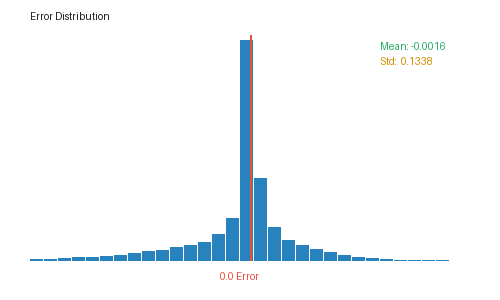

In [38]:
import numpy as np
from PIL import Image, ImageDraw
import torch

model.eval()
all_preds = []
all_trues = []
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

with torch.no_grad():
    for imgs, labels in val_loader:
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            outputs = model(imgs)
        all_preds.append(outputs.cpu().float().numpy())
        all_trues.append(labels.cpu().float().numpy())

preds_matrix = np.vstack(all_preds)
trues_matrix = np.vstack(all_trues)

residuals = preds_matrix - trues_matrix # Values range from -1.0 to +1.0
flattened_residuals = residuals.flatten()

mean_val = np.mean(flattened_residuals)
std_val = np.std(flattened_residuals)

counts, bin_edges = np.histogram(flattened_residuals, bins=30, range=(-0.5, 0.5))

graph_w, graph_h = 500, 300
canvas = Image.new("RGB", (graph_w, graph_h), (255, 255, 255))
draw = ImageDraw.Draw(canvas)

max_count = max(counts) if max(counts) > 0 else 1
bar_w = (graph_w - 60) // len(counts)

for i, count in enumerate(counts):
    bar_h = int((count / max_count) * (graph_h - 80))
    x0 = 30 + (i * bar_w)
    y0 = graph_h - 40 - bar_h
    x1 = x0 + bar_w - 2
    y1 = graph_h - 40
    draw.rectangle([x0, y0, x1, y1], fill=(40, 130, 190))

center_x = graph_w // 2
draw.line([center_x, 35, center_x, graph_h - 40], fill=(230, 80, 60), width=2)
draw.text((center_x - 30, graph_h - 30), "0.0 Error", fill=(230, 80, 60))
draw.text((30, 10), "Error Distribution", fill=(30, 30, 30))

text_x = graph_w - 120
draw.text((text_x, 40), f"Mean: {mean_val:+.4f}", fill=(40, 170, 100)) # Green accent
draw.text((text_x, 55), f"Std:  {std_val:.4f}", fill=(210, 140, 0))   # Yellow accent
display(canvas)
